# 🌦️ Open-Meteo Flood & Weather API Analysis
This notebook covers:
- Data collection using Open-Meteo APIs
- EDA for rainfall, temperature, wind, and river discharge
- Feature engineering for CNN–LSTM flood prediction model.

In [1]:
# ============================================================
# 📦 Environment Setup — Install Required Libraries
# ============================================================

!pip install --upgrade pip

# Data handling & analysis
!pip install pandas numpy requests requests-cache retry requests retry_requests

# Visualization
!pip install matplotlib seaborn

# Deep learning (for CNN–LSTM)
!pip install tensorflow scikit-learn

# Open-Meteo API support
!pip install openmeteo-requests

# Optional (for interactive exploration or missing data visualization)
%pip install tqdm missingno

!pip install jinja2

# for Hyperparameter Tuning
!pip install keras-tuner

print("✅ All required packages installed successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [requests-cache]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.3/731.3 kB 21.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.3 MB/s  0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [openmeteo-requests]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [keras-tuner]
✅ All required packages installed successfully!


## 1️⃣ Data Collection — Open-Meteo Weather API

In [2]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
locations = [
    {"name": "Petaling", "latitude": 3.107260, "longitude": 101.606710},
    {"name": "Klang", "latitude": 3.043092, "longitude": 101.441392}
]

common_params = {
    "start_date": "2010-01-01",
    "end_date": "2025-12-31",
    "daily": ["rain_sum","precipitation_sum","temperature_2m_mean","wind_speed_10m_max","wind_gusts_10m_max"],
    "timezone": "Asia/Kuala_Lumpur"
}

all_daily = []
for loc in locations:
    params = common_params | {"latitude": loc["latitude"], "longitude": loc["longitude"]}
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    daily = response.Daily()
    daily_data = {
        "date": pd.date_range(start=pd.to_datetime(daily.Time(), unit='s', utc=True),
                              end=pd.to_datetime(daily.TimeEnd(), unit='s', utc=True),
                              freq=pd.Timedelta(seconds=daily.Interval()), inclusive='left'),
        "rain_sum_mm": daily.Variables(0).ValuesAsNumpy(),
        "precipitation_sum_mm": daily.Variables(1).ValuesAsNumpy(),
        "temperature_mean_°C": daily.Variables(2).ValuesAsNumpy(),
        "wind_speed_max_mps": daily.Variables(3).ValuesAsNumpy(),
        "wind_gust_max_mps": daily.Variables(4).ValuesAsNumpy(),
        "location": loc["name"]
    }
    all_daily.append(pd.DataFrame(daily_data))

daily_df = pd.concat(all_daily, ignore_index=True)
print(f"✅ Combined records: {len(daily_df)}")
daily_df.head()

✅ Combined records: 11688


,date,rain_sum_mm,precipitation_sum_mm,temperature_mean_°C,wind_speed_max_mps,wind_gust_max_mps,location
0,2009-12-31 16:00:00+00:00,38.599998,38.599998,25.033831,9.346143,24.840000,Petaling
1,2010-01-01 16:00:00+00:00,31.100002,31.100002,25.575500,8.049845,27.359999,Petaling
2,2010-01-02 16:00:00+00:00,13.600000,13.600000,25.858831,10.086427,20.160000,Petaling
3,2010-01-03 16:00:00+00:00,26.400002,26.400002,25.892168,11.013882,21.240000,Petaling
4,2010-01-04 16:00:00+00:00,0.800000,0.800000,26.271334,11.212135,17.639999,Petaling


## 2️⃣ Data Collection — Open-Meteo Flood API

In [3]:
url_flood = "https://flood-api.open-meteo.com/v1/flood"
common_params = {
    "start_date": "2010-01-01",
    "end_date": "2025-12-31",
    "daily": ["river_discharge"],
    "timezone": "Asia/Kuala_Lumpur"
}

all_discharge = []
for loc in locations:
    params = common_params | {"latitude": loc["latitude"], "longitude": loc["longitude"]}
    responses = openmeteo.weather_api(url_flood, params=params)
    response = responses[0]
    daily = response.Daily()
    discharge_data = {
        "date": pd.date_range(start=pd.to_datetime(daily.Time(), unit='s', utc=True),
                              end=pd.to_datetime(daily.TimeEnd(), unit='s', utc=True),
                              freq=pd.Timedelta(seconds=daily.Interval()), inclusive='left'),
        "river_discharge_m3s": daily.Variables(0).ValuesAsNumpy(),
        "location": loc["name"]
    }
    all_discharge.append(pd.DataFrame(discharge_data))

discharge_df = pd.concat(all_discharge, ignore_index=True)
print(f"✅ Combined records: {len(discharge_df)}")
discharge_df.head()

✅ Combined records: 11688


,date,river_discharge_m3s,location
0,2009-12-31 16:00:00+00:00,23.774223,Petaling
1,2010-01-01 16:00:00+00:00,39.086678,Petaling
2,2010-01-02 16:00:00+00:00,57.884361,Petaling
3,2010-01-03 16:00:00+00:00,76.624710,Petaling
4,2010-01-04 16:00:00+00:00,61.230034,Petaling


## 4️⃣.1️⃣ Feature Engineering for CNN–LSTM (Hydrological - Flood)

In [4]:
# ============================================================
# 🌊 Feature Engineering — Open-Meteo Flood (discharge_df)
# ============================================================

import pandas as pd
import numpy as np

# --- Convert and sort ---
discharge_df["date"] = pd.to_datetime(discharge_df["date"])
discharge_df = discharge_df.sort_values(["location", "date"]).reset_index(drop=True)

print(f"\n✅ Discharge dataset loaded: {len(discharge_df)} records")
print(f"Date range: {discharge_df['date'].min()} → {discharge_df['date'].max()}")
print(f"Locations: {discharge_df['location'].unique()}")

# ============================================================
# 1️⃣ HYDROLOGICAL FEATURES
# ============================================================

# Lag features
for lag in [1, 3, 7]:
    discharge_df[f"discharge_lag_{lag}d"] = discharge_df.groupby("location")["river_discharge_m3s"].shift(lag)

# Rolling averages and cumulative sums
discharge_df["discharge_rolling_3d"] = discharge_df.groupby("location")["river_discharge_m3s"].transform(lambda x: x.rolling(3).mean())
discharge_df["discharge_cum_7d"] = discharge_df.groupby("location")["river_discharge_m3s"].transform(lambda x: x.rolling(7).sum())

# Discharge rate of change
discharge_df["discharge_delta_1d"] = discharge_df.groupby("location")["river_discharge_m3s"].diff(1)
discharge_df["discharge_change_pct"] = discharge_df.groupby("location")["river_discharge_m3s"].pct_change()

# Anomaly detection (deviation from 3-day mean)
discharge_df["discharge_anomaly"] = discharge_df["river_discharge_m3s"] - discharge_df["discharge_rolling_3d"]

# ============================================================
# 2️⃣ EXTREME RIVER DISCHARGE EVENT DETECTION
# ============================================================

# Compute extreme discharge threshold (e.g., top 5%)
flood_threshold = discharge_df["river_discharge_m3s"].quantile(0.95)

# Flag for extreme floods
discharge_df["is_extreme_river_discharge"] = (discharge_df["river_discharge_m3s"] >= flood_threshold).astype(int)

# Z-score normalization to highlight anomalies
discharge_df["discharge_zscore"] = (
    (discharge_df["river_discharge_m3s"] - discharge_df["river_discharge_m3s"].mean())
    / discharge_df["river_discharge_m3s"].std()
)

# Count extreme days
n_extreme = discharge_df["is_extreme_river_discharge"].sum()
print(f"\n⚠️ Extreme Flood Events Detected (≥95th percentile, ≥{flood_threshold:.2f} m³/s): {n_extreme} days")

# # Preview top extreme events
# display(
#     discharge_df[discharge_df["is_extreme_river_discharge"] == 1]
#     .sort_values(by="river_discharge_m3s", ascending=False)
#     .head(10)
# )

# ============================================================
# 3️⃣ TIME FEATURES (for model alignment)
# ============================================================

discharge_df["dayofyear"] = discharge_df["date"].dt.dayofyear
discharge_df["month"] = discharge_df["date"].dt.month
discharge_df["weekday"] = discharge_df["date"].dt.weekday
discharge_df["is_weekend"] = discharge_df["weekday"].isin([5, 6]).astype(int)

# ============================================================
# 4️⃣ CLEANING
# ============================================================

# Forward-fill and backward-fill missing data per location
discharge_df = discharge_df.groupby("location").apply(lambda g: g.ffill().bfill()).reset_index(drop=True)

# Drop any remaining missing discharge
discharge_df = discharge_df.dropna(subset=["river_discharge_m3s"])

print("\n✅ Flood feature engineering completed successfully.")
print(f"Final shape: {discharge_df.shape}")
print(f"New columns added: {[c for c in discharge_df.columns if 'discharge_' in c and c not in ['river_discharge_m3s']]}")

# --- Optional save ---
# discharge_df.to_csv("features_flood_discharge_extreme.csv", index=False)

# --- Optional plot (uncomment if needed) ---
# import matplotlib.pyplot as plt
# import seaborn as sns
# plt.figure(figsize=(10, 5))
# sns.scatterplot(x="date", y="river_discharge_m3s", data=discharge_df, hue="location", alpha=0.6)
# sns.scatterplot(
#     x="date", y="river_discharge_m3s",
#     data=discharge_df[discharge_df["is_extreme_river_discharge"] == 1],
#     color="red", s=30, label="Extreme Floods"
# )
# plt.title("Extreme Flood Events (≥95th Percentile)")
# plt.xlabel("Date")
# plt.ylabel("Discharge (m³/s)")
# plt.legend()
# plt.tight_layout()
# plt.show()

# --- Display Final Output ---
display(discharge_df.head(10))



✅ Discharge dataset loaded: 11688 records
Date range: 2009-12-31 16:00:00+00:00 → 2025-12-30 16:00:00+00:00
Locations: ['Klang' 'Petaling']

⚠️ Extreme Flood Events Detected (≥95th percentile, ≥126.64 m³/s): 587 days

✅ Flood feature engineering completed successfully.
Final shape: (11688, 17)
New columns added: ['discharge_lag_1d', 'discharge_lag_3d', 'discharge_lag_7d', 'discharge_rolling_3d', 'discharge_cum_7d', 'discharge_delta_1d', 'discharge_change_pct', 'discharge_anomaly', 'discharge_zscore']


/tmp/ipykernel_2543/2179323484.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  discharge_df = discharge_df.groupby("location").apply(lambda g: g.ffill().bfill()).reset_index(drop=True)


,date,river_discharge_m3s,location,discharge_lag_1d,discharge_lag_3d,discharge_lag_7d,discharge_rolling_3d,discharge_cum_7d,discharge_delta_1d,discharge_change_pct,discharge_anomaly,is_extreme_river_discharge,discharge_zscore,dayofyear,month,weekday,is_weekend
0,2009-12-31 16:00:00+00:00,63.714256,Klang,63.714256,63.714256,63.714256,123.560733,976.486229,60.599876,0.951120,59.093076,0,0.488608,365,12,3,0
1,2010-01-01 16:00:00+00:00,124.314133,Klang,63.714256,63.714256,63.714256,123.560733,976.486229,60.599876,0.951120,59.093076,0,1.919988,1,1,4,0
2,2010-01-02 16:00:00+00:00,182.653809,Klang,124.314133,63.714256,63.714256,123.560733,976.486229,58.339676,0.469292,59.093076,1,3.297981,2,1,5,1
3,2010-01-03 16:00:00+00:00,228.086716,Klang,182.653809,63.714256,63.714256,178.351552,976.486229,45.432907,0.248738,49.735163,1,4.371114,3,1,6,1
4,2010-01-04 16:00:00+00:00,168.824371,Klang,228.086716,124.314133,63.714256,193.188299,976.486229,-59.262344,-0.259824,-24.363927,1,2.971327,4,1,0,0
5,2010-01-05 16:00:00+00:00,113.287857,Klang,168.824371,182.653809,63.714256,170.066315,976.486229,-55.536514,-0.328960,-56.778458,0,1.659545,5,1,1,0
6,2010-01-06 16:00:00+00:00,95.605087,Klang,113.287857,228.086716,63.714256,125.905772,976.486229,-17.682770,-0.156087,-30.300685,0,1.241875,6,1,2,0
7,2010-01-07 16:00:00+00:00,76.446190,Klang,95.605087,168.824371,63.714256,95.113045,989.218163,-19.158897,-0.200396,-18.666855,0,0.789339,7,1,3,0
8,2010-01-08 16:00:00+00:00,69.307236,Klang,76.446190,113.287857,124.314133,80.452838,934.211266,-7.138954,-0.093385,-11.145602,0,0.620715,8,1,4,0
9,2010-01-09 16:00:00+00:00,58.566212,Klang,69.307236,95.605087,182.653809,68.106546,810.123669,-10.741024,-0.154977,-9.540334,0,0.367010,9,1,5,1


## 4️⃣.2️⃣ Feature Engineering for CNN–LSTM (Meteorological - Temporal)

In [5]:
# ============================================================
# 🌦️ Feature Engineering — Open-Meteo Weather (daily_df)
# ============================================================

import pandas as pd
import numpy as np

# --- Convert and sort date ---
daily_df["date"] = pd.to_datetime(daily_df["date"])
daily_df = daily_df.sort_values(["location", "date"]).reset_index(drop=True)

print(f"\n✅ Weather dataset loaded: {len(daily_df)} records")
print(f"Date range: {daily_df['date'].min()} → {daily_df['date'].max()}")
print(f"Locations: {daily_df['location'].unique()}")

# ============================================================
# 1️⃣ TEMPORAL FEATURES
# ============================================================

# Lag features for rainfall, temperature, and wind
for lag in [1, 3, 7]:
    daily_df[f"rain_lag_{lag}d"] = daily_df.groupby("location")["rain_sum_mm"].shift(lag)
    daily_df[f"temp_lag_{lag}d"] = daily_df.groupby("location")["temperature_mean_°C"].shift(lag)

# Rolling stats
daily_df["rain_rolling_3d"] = daily_df.groupby("location")["rain_sum_mm"].transform(lambda x: x.rolling(3).mean())
daily_df["rain_cum_7d"] = daily_df.groupby("location")["rain_sum_mm"].transform(lambda x: x.rolling(7).sum())

# Calendar features
daily_df["dayofyear"] = daily_df["date"].dt.dayofyear
daily_df["month"] = daily_df["date"].dt.month
daily_df["weekday"] = daily_df["date"].dt.weekday
daily_df["is_weekend"] = daily_df["weekday"].isin([5, 6]).astype(int)

# ============================================================
# 2️⃣ METEOROLOGICAL FEATURES
# ============================================================

# Combined atmospheric index
daily_df["atmo_index"] = (
    daily_df["rain_sum_mm"].fillna(0)
    + daily_df["precipitation_sum_mm"].fillna(0)
    + (daily_df["wind_speed_max_mps"].fillna(0) * 0.5)
)

# Air-water interaction proxy
daily_df["temp_wind_interaction"] = (
    daily_df["temperature_mean_°C"].fillna(0)
    * daily_df["wind_speed_max_mps"].fillna(0)
)

# ============================================================
# 3️⃣ EXTREME WEATHER EVENT DETECTION
# ============================================================

# Define thresholds (95th percentile)
rain_threshold = daily_df["rain_sum_mm"].quantile(0.95)
temp_threshold = daily_df["temperature_mean_°C"].quantile(0.95)
wind_threshold = daily_df["wind_speed_max_mps"].quantile(0.95)

# Create binary flags for extremes
daily_df["extreme_rain"] = (daily_df["rain_sum_mm"] >= rain_threshold).astype(int)
daily_df["extreme_temp"] = (daily_df["temperature_mean_°C"] >= temp_threshold).astype(int)
daily_df["extreme_wind"] = (daily_df["wind_speed_max_mps"] >= wind_threshold).astype(int)

# Composite extreme weather flag
daily_df["is_extreme_weather"] = (
    (daily_df["extreme_rain"] + daily_df["extreme_temp"] + daily_df["extreme_wind"]) > 0
).astype(int)

# Z-scores for anomaly intensity
for col in ["rain_sum_mm", "temperature_mean_°C", "wind_speed_max_mps"]:
    z_col = col.replace("_mm", "_zscore").replace("_°C", "_zscore").replace("_mps", "_zscore")
    daily_df[z_col] = (daily_df[col] - daily_df[col].mean()) / daily_df[col].std()

# Print summary
print("\n⚠️ Extreme Weather Detection Summary:")
print(f"Rainfall ≥ {rain_threshold:.2f} mm → {daily_df['extreme_rain'].sum()} days")
print(f"Temperature ≥ {temp_threshold:.2f}°C → {daily_df['extreme_temp'].sum()} days")
print(f"Wind Speed ≥ {wind_threshold:.2f} m/s → {daily_df['extreme_wind'].sum()} days")
print(f"Total Extreme Weather Days: {daily_df['is_extreme_weather'].sum()}")

# # Preview top 10 extreme events
# display(
#     daily_df[daily_df["is_extreme_weather"] == 1]
#     .sort_values(by=["rain_sum_mm", "temperature_mean_°C", "wind_speed_max_mps"], ascending=False)
#     .head(10)
# )

# ============================================================
# 4️⃣ CLEANING
# ============================================================

# Fill missing by location
daily_df = daily_df.groupby("location").apply(lambda g: g.ffill().bfill()).reset_index(drop=True)
daily_df = daily_df.dropna(subset=["rain_sum_mm", "temperature_mean_°C"])

print("\n✅ Weather feature engineering completed successfully.")
print(f"Final shape: {daily_df.shape}")
print(f"New columns added: {[c for c in daily_df.columns if 'lag' in c or 'rolling' in c or 'extreme' in c or 'zscore' in c or 'atmo' in c]}")

# --- Optional save ---
# daily_df.to_csv("features_weather_daily_extreme.csv", index=False)

# --- Optional visualization ---
# import matplotlib.pyplot as plt
# import seaborn as sns
# plt.figure(figsize=(10, 5))
# sns.scatterplot(
#     x="date", y="rain_sum_mm", data=daily_df, hue="location", alpha=0.6
# )
# sns.scatterplot(
#     x="date", y="rain_sum_mm",
#     data=daily_df[daily_df["is_extreme_weather"] == 1],
#     color="red", s=40, label="Extreme Weather"
# )
# plt.title("Extreme Weather Days (≥95th Percentile)")
# plt.xlabel("Date")
# plt.ylabel("Rainfall (mm)")
# plt.legend()
# plt.tight_layout()
# plt.show()

# --- Display final dataset preview ---
display(daily_df.head(10))



✅ Weather dataset loaded: 11688 records
Date range: 2009-12-31 16:00:00+00:00 → 2025-12-30 16:00:00+00:00
Locations: ['Klang' 'Petaling']

⚠️ Extreme Weather Detection Summary:
Rainfall ≥ 25.80 mm → 585 days
Temperature ≥ 28.20°C → 585 days
Wind Speed ≥ 16.06 m/s → 589 days
Total Extreme Weather Days: 1658

✅ Weather feature engineering completed successfully.
Final shape: (11688, 28)
New columns added: ['rain_lag_1d', 'temp_lag_1d', 'rain_lag_3d', 'temp_lag_3d', 'rain_lag_7d', 'temp_lag_7d', 'rain_rolling_3d', 'atmo_index', 'extreme_rain', 'extreme_temp', 'extreme_wind', 'is_extreme_weather', 'rain_sum_zscore', 'temperature_mean_zscore', 'wind_speed_max_zscore']


/tmp/ipykernel_2543/869206292.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_df = daily_df.groupby("location").apply(lambda g: g.ffill().bfill()).reset_index(drop=True)


,date,rain_sum_mm,precipitation_sum_mm,temperature_mean_°C,wind_speed_max_mps,wind_gust_max_mps,location,rain_lag_1d,temp_lag_1d,rain_lag_3d,...,is_weekend,atmo_index,temp_wind_interaction,extreme_rain,extreme_temp,extreme_wind,is_extreme_weather,rain_sum_zscore,temperature_mean_zscore,wind_speed_max_zscore
0,2009-12-31 16:00:00+00:00,38.599998,38.599998,25.592752,9.346143,24.840000,Klang,38.599998,25.592752,38.599998,...,0,81.873070,239.193512,1,0,0,1,3.280982,-1.099244,-0.598947
1,2010-01-01 16:00:00+00:00,31.100002,31.100002,26.153168,8.049845,27.359999,Klang,38.599998,25.592752,38.599998,...,0,66.224930,210.528946,1,0,0,1,2.486732,-0.499369,-1.066541
2,2010-01-02 16:00:00+00:00,13.600000,13.600000,26.505251,10.086427,20.160000,Klang,31.100002,26.153168,38.599998,...,1,32.243214,267.343262,0,0,0,0,0.633480,-0.122495,-0.331915
3,2010-01-03 16:00:00+00:00,26.400002,26.400002,26.476082,11.013882,21.240000,Klang,13.600000,26.505251,38.599998,...,1,58.306946,291.604431,1,0,0,1,1.989001,-0.153718,0.002632
4,2010-01-04 16:00:00+00:00,0.800000,0.800000,27.009420,11.212135,17.639999,Klang,26.400002,26.476082,31.100002,...,0,7.206068,302.833282,0,0,0,0,-0.722041,0.417174,0.074145
5,2010-01-05 16:00:00+00:00,0.500000,0.500000,27.190664,11.525623,27.719999,Klang,0.800000,27.009420,13.600000,...,0,6.762812,313.389343,0,0,0,0,-0.753811,0.611180,0.187225
6,2010-01-06 16:00:00+00:00,4.500000,4.500000,26.823999,11.183201,22.680000,Klang,0.500000,27.190664,26.400002,...,0,14.591600,299.978180,0,0,0,0,-0.330211,0.218697,0.063708
7,2010-01-07 16:00:00+00:00,4.600000,4.600000,26.469835,11.631956,30.239998,Klang,4.500000,26.823999,0.800000,...,0,15.015979,307.895966,0,0,0,0,-0.319621,-0.160404,0.225581
8,2010-01-08 16:00:00+00:00,1.100000,1.100000,26.378164,6.109403,25.559999,Klang,4.600000,26.469835,0.500000,...,0,5.254702,161.154831,0,0,0,0,-0.690271,-0.258530,-1.766488
9,2010-01-09 16:00:00+00:00,4.800000,4.800000,26.069832,10.630672,28.799999,Klang,1.100000,26.378164,4.500000,...,1,14.915337,277.139832,0,0,0,0,-0.298441,-0.588573,-0.135597


## 5️⃣ CNN–LSTM Model Training & Evaluation


✅ Merged dataset created: 11688 records
Date range: 2009-12-31 16:00:00+00:00 → 2025-12-30 16:00:00+00:00
Locations: ['Klang' 'Petaling']

🧩 Features used (24): ['rain_sum_mm', 'precipitation_sum_mm', 'temperature_mean_°C', 'wind_speed_max_mps', 'wind_gust_max_mps', 'atmo_index', 'temp_wind_interaction', 'rain_lag_1d', 'rain_lag_3d', 'rain_rolling_3d', 'rain_cum_7d', 'rain_sum_zscore', 'temperature_mean_zscore', 'is_extreme_weather', 'discharge_lag_1d', 'discharge_lag_3d', 'discharge_rolling_3d', 'discharge_cum_7d', 'discharge_delta_1d', 'discharge_anomaly', 'discharge_zscore', 'dayofyear_flood', 'month_flood', 'weekday_flood']

⚙️ No explicit extreme flag found. Using threshold ≥ 65.83 m³/s
Flood event ratio: 0.200

🧠 X_train shape: (9344, 7, 24)
🧠 y_train shape: (9344,)
Flood ratio in training: 0.233


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 64)          │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,273 (149.50 KB)

 Trainable params: 38,273 (149.50 KB)

 Non-trainable params: 0 (0.00 B)


⚖️ Class Weights: {0: np.float64(0.6522406812787938), 1: np.float64(2.1421366345712975)}
Epoch 1/60
468/468 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8607 - loss: 0.3318 - val_accuracy: 0.8967 - val_loss: 0.2179
Epoch 2/60
468/468 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8932 - loss: 0.2623 - val_accuracy: 0.8994 - val_loss: 0.2195
Epoch 3/60
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8916 - loss: 0.2504 - val_accuracy: 0.9155 - val_loss: 0.1989
Epoch 4/60
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8999 - loss: 0.2392 - val_accuracy: 0.9155 - val_loss: 0.1765
Epoch 5/60
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9018 - loss: 0.2328 - val_accuracy: 0.9283 - val_loss: 0.1628
Epoch 6/60
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9046 - loss: 0.2270 - val_accuracy: 0.8957 - val_loss: 0.2086
Epoch 7/60
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9077 - loss: 0.2203 - val_accuracy: 0.8882 - val_loss: 0.2321
Epoch 8/60
4

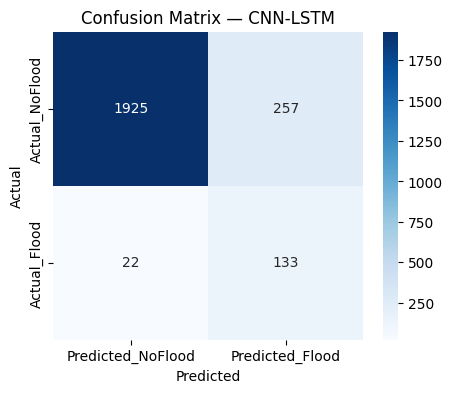


🧾 Confusion Matrix (Table Format):


,Predicted_NoFlood,Predicted_Flood
Actual_NoFlood,1925,257
Actual_Flood,22,133



Detailed Classification Report:

              precision    recall  f1-score   support

    No Flood       0.99      0.88      0.93      2182
       Flood       0.34      0.86      0.49       155

    accuracy                           0.88      2337
   macro avg       0.66      0.87      0.71      2337
weighted avg       0.95      0.88      0.90      2337



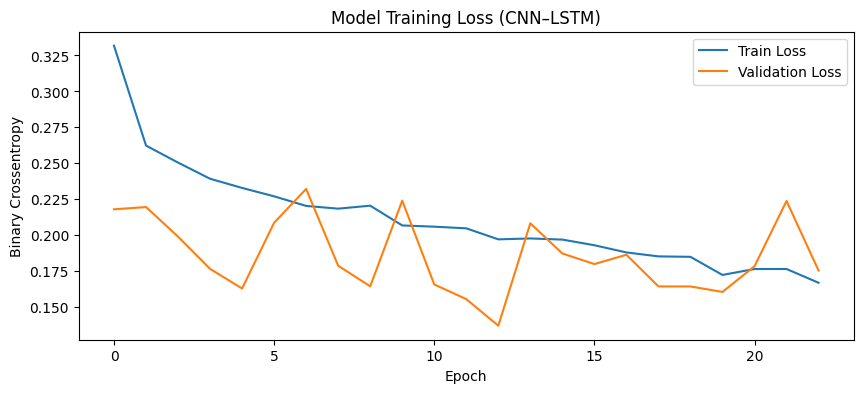

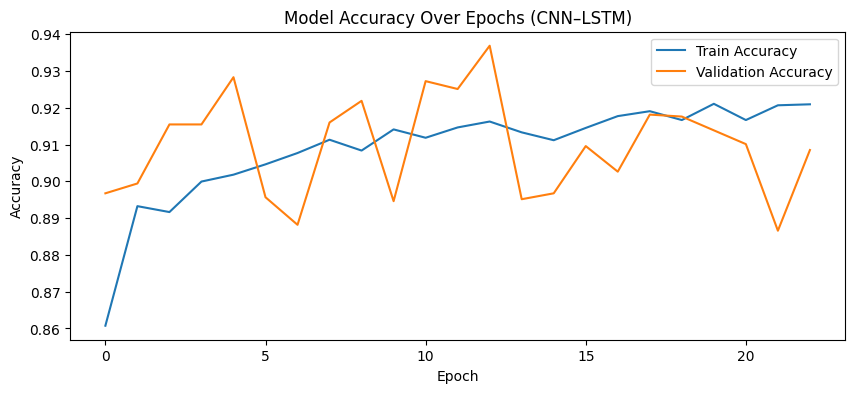

In [6]:
    # ============================================================
    # 🤖 CNN–LSTM Model Training & Evaluation
    # Datasets: Open-Meteo Weather (daily_df) + Flood (discharge_df)
    # Includes Extreme Event & Z-Score Features
    # ============================================================

    import numpy as np
    import pandas as pd
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils import class_weight
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        confusion_matrix, classification_report
    )
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Dropout, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ============================================================
    # 1️⃣ DATA MERGING — Weather + Flood
    # ============================================================

    # Merge weather and discharge features on date + location
    merged = pd.merge(
        daily_df,
        discharge_df,
        on=["date", "location"],
        suffixes=("_weather", "_flood")
    ).dropna(subset=["river_discharge_m3s"])

    print(f"\n✅ Merged dataset created: {len(merged)} records")
    print(f"Date range: {merged['date'].min()} → {merged['date'].max()}")
    print(f"Locations: {merged['location'].unique()}")

    # ============================================================
    # 2️⃣ FEATURE SELECTION
    # ============================================================

    feature_cols = [
        # Weather variables
        "rain_sum_mm", "precipitation_sum_mm", "temperature_mean_°C",
        "wind_speed_max_mps", "wind_gust_max_mps", "atmo_index",
        "temp_wind_interaction", "rain_lag_1d", "rain_lag_3d",
        "rain_rolling_3d", "rain_cum_7d",

        # Z-score & extreme weather features
        "rain_sum_zscore", "temperature_mean_zscore", "wind_speed_zscore",
        "is_extreme_weather",

        # Flood variables
        "discharge_lag_1d", "discharge_lag_3d", "discharge_rolling_3d",
        "discharge_cum_7d", "discharge_delta_1d", "discharge_anomaly",
        "discharge_zscore",

        # Time features
        "dayofyear_flood", "month_flood", "weekday_flood"
    ]

    # Ensure columns exist
    feature_cols = [c for c in feature_cols if c in merged.columns]
    print(f"\n🧩 Features used ({len(feature_cols)}): {feature_cols}")

    # ============================================================
    # 3️⃣ TARGET VARIABLE — Extreme Flood Flag
    # ============================================================

    if "is_extreme_flood" in merged.columns:
        merged["flood_label"] = merged["is_extreme_flood"]
        print("\n🌊 Using `is_extreme_flood` as target variable.")
    else:
        threshold = merged["river_discharge_m3s"].quantile(0.8)
        merged["flood_label"] = (merged["river_discharge_m3s"] >= threshold).astype(int)
        print(f"\n⚙️ No explicit extreme flag found. Using threshold ≥ {threshold:.2f} m³/s")

    print(f"Flood event ratio: {merged['flood_label'].mean():.3f}")

    # ============================================================
    # 4️⃣ SCALING & SEQUENCE CREATION
    # ============================================================

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(merged[feature_cols])
    scaled_df = pd.DataFrame(scaled_features, columns=feature_cols)
    scaled_df["flood_label"] = merged["flood_label"].values

    # Function to create time-series sequences
    def create_sequences(data, labels, lookback=7):
        X, y = [], []
        for i in range(lookback, len(data)):
            X.append(data[i - lookback:i])
            y.append(labels[i])
        return np.array(X), np.array(y)

    # Create sequences
    X, y = create_sequences(
        scaled_df[feature_cols].values,
        scaled_df["flood_label"].values,
        lookback=7
    )

    # Split into train/test (no shuffle — preserve time order)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    print(f"\n🧠 X_train shape: {X_train.shape}")
    print(f"🧠 y_train shape: {y_train.shape}")
    print(f"Flood ratio in training: {y_train.mean():.3f}")

    # ============================================================
    # 5️⃣ MODEL DEFINITION — CNN–LSTM
    # ============================================================

    model = Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

    # ============================================================
    # 6️⃣ MODEL TRAINING (Weighted for Flood Class)
    # ============================================================

    # Handle class imbalance
    weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = {0: weights[0], 1: weights[1]}
    print("\n⚖️ Class Weights:", class_weights)

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=60,
        batch_size=16,
        class_weight=class_weights,
        callbacks=[es],
        verbose=1
    )

    # ============================================================
    # 7️⃣ PERFORMANCE EVALUATION
    # ============================================================

    y_pred_prob = model.predict(X_test)
    # Slightly lower threshold to favor flood recall
    y_pred = (y_pred_prob > 0.4).astype(int)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n📊 Model Performance Metrics (threshold=0.4):")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # ============================================================
    # 8️⃣ CONFUSION MATRIX & REPORT
    # ============================================================

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm,
                        index=['Actual_NoFlood', 'Actual_Flood'],
                        columns=['Predicted_NoFlood', 'Predicted_Flood'])

    # Heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix — CNN-LSTM")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    print("\n🧾 Confusion Matrix (Table Format):")
    display(cm_df)

    # Detailed report
    print("\nDetailed Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['No Flood','Flood']))

    # ============================================================
    # 9️⃣ TRAINING VISUALIZATION
    # ============================================================

    plt.figure(figsize=(10,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Training Loss (CNN–LSTM)')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentropy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy Over Epochs (CNN–LSTM)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


# 70% Train, 15% Val, 15% Test


✅ Merged dataset created: 11688 records
Date range: 2009-12-31 16:00:00+00:00 → 2025-12-30 16:00:00+00:00
Locations: ['Klang' 'Petaling']

🧩 Features used (24): ['rain_sum_mm', 'precipitation_sum_mm', 'temperature_mean_°C', 'wind_speed_max_mps', 'wind_gust_max_mps', 'atmo_index', 'temp_wind_interaction', 'rain_lag_1d', 'rain_lag_3d', 'rain_rolling_3d', 'rain_cum_7d', 'rain_sum_zscore', 'temperature_mean_zscore', 'is_extreme_weather', 'discharge_lag_1d', 'discharge_lag_3d', 'discharge_rolling_3d', 'discharge_cum_7d', 'discharge_delta_1d', 'discharge_anomaly', 'discharge_zscore', 'dayofyear_flood', 'month_flood', 'weekday_flood']

⚙️ Threshold for extreme flood: ≥ 65.83 m³/s
Flood ratio: 0.200

📦 Sequence dataset size: (11681, 7, 24), labels: (11681,)

📌 Time-series split:
Train: (8176, 7, 24) (70.0%)
Val:   (1752, 7, 24) (15.0%)
Test:  (1753, 7, 24) (15.0%)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,273 (149.50 KB)

 Trainable params: 38,273 (149.50 KB)

 Non-trainable params: 0 (0.00 B)


⚖️ Class weights: {0: np.float64(0.6770453792646571), 1: np.float64(1.912067352666043)}
Epoch 1/60
511/511 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8697 - loss: 0.3042 - val_accuracy: 0.8916 - val_loss: 0.2573
Epoch 2/60
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9018 - loss: 0.2428 - val_accuracy: 0.8818 - val_loss: 0.2341
Epoch 3/60
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9039 - loss: 0.2316 - val_accuracy: 0.9161 - val_loss: 0.1798
Epoch 4/60
511/511 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9068 - loss: 0.2184 - val_accuracy: 0.9144 - val_loss: 0.1795
Epoch 5/60
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9116 - loss: 0.2129 - val_accuracy: 0.9184 - val_loss: 0.1584
Epoch 6/60
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9125 - loss: 0.2126 - val_accuracy: 0.9064 - val_loss: 0.1896
Epoch 7/60
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9123 - loss: 0.2058 - val_accuracy: 0.9064 - val_loss: 0.1949
Epoch 8/60
511/

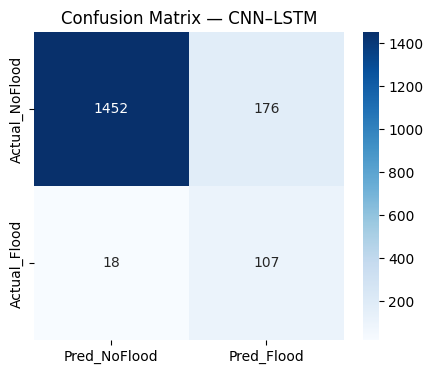


🧾 Classification Report:
              precision    recall  f1-score   support

    No Flood       0.99      0.89      0.94      1628
       Flood       0.38      0.86      0.52       125

    accuracy                           0.89      1753
   macro avg       0.68      0.87      0.73      1753
weighted avg       0.94      0.89      0.91      1753



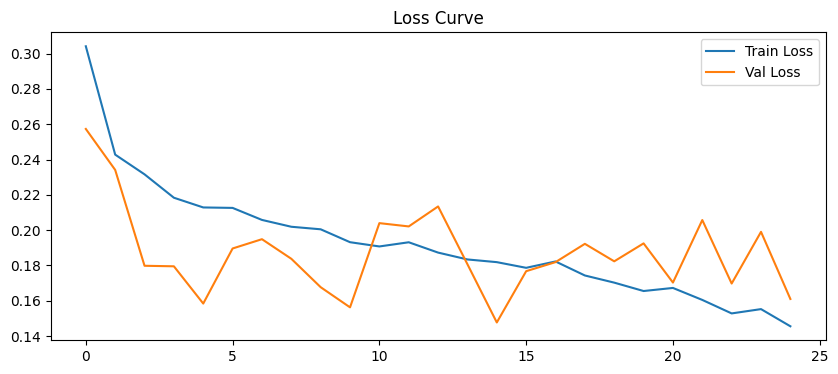

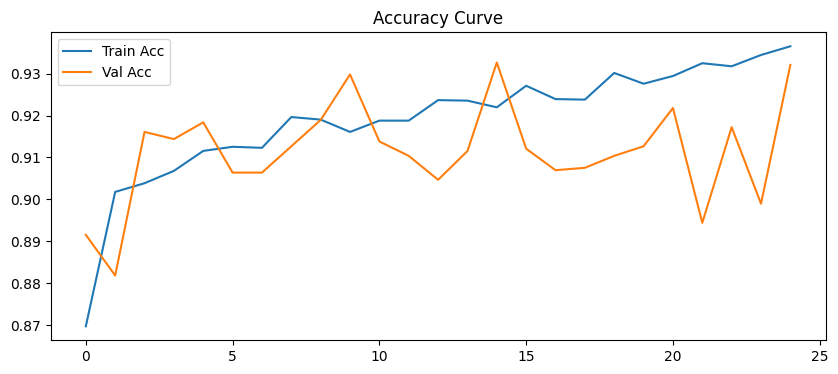

In [7]:
# ============================================================
# 🤖 CNN–LSTM Model Training & Evaluation (70/15/15 Split)
# Datasets: Open-Meteo Weather (daily_df) + Flood (discharge_df)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1️⃣ DATA MERGING — Weather + Flood
# ============================================================

merged = pd.merge(
    daily_df,
    discharge_df,
    on=["date", "location"],
    suffixes=("_weather", "_flood")
).dropna(subset=["river_discharge_m3s"])

print(f"\n✅ Merged dataset created: {len(merged)} records")
print(f"Date range: {merged['date'].min()} → {merged['date'].max()}")
print(f"Locations: {merged['location'].unique()}")

# ============================================================
# 2️⃣ FEATURE SELECTION
# ============================================================

feature_cols = [
    "rain_sum_mm", "precipitation_sum_mm", "temperature_mean_°C",
    "wind_speed_max_mps", "wind_gust_max_mps", "atmo_index",
    "temp_wind_interaction", "rain_lag_1d", "rain_lag_3d",
    "rain_rolling_3d", "rain_cum_7d",
    "rain_sum_zscore", "temperature_mean_zscore", "wind_speed_zscore",
    "is_extreme_weather",
    "discharge_lag_1d", "discharge_lag_3d", "discharge_rolling_3d",
    "discharge_cum_7d", "discharge_delta_1d", "discharge_anomaly",
    "discharge_zscore",
    "dayofyear_flood", "month_flood", "weekday_flood"
]

feature_cols = [c for c in feature_cols if c in merged.columns]
print(f"\n🧩 Features used ({len(feature_cols)}): {feature_cols}")

# ============================================================
# 3️⃣ TARGET VARIABLE — Extreme Flood or Threshold
# ============================================================

if "is_extreme_flood" in merged.columns:
    merged["flood_label"] = merged["is_extreme_flood"]
    print("\n🌊 Using `is_extreme_flood` as target.")
else:
    threshold = merged["river_discharge_m3s"].quantile(0.8)
    merged["flood_label"] = (merged["river_discharge_m3s"] >= threshold).astype(int)
    print(f"\n⚙️ Threshold for extreme flood: ≥ {threshold:.2f} m³/s")

print(f"Flood ratio: {merged['flood_label'].mean():.3f}")

# ============================================================
# 4️⃣ SCALING + SEQUENCE CREATION
# ============================================================

scaler = StandardScaler()
scaled_features = scaler.fit_transform(merged[feature_cols])
scaled_df = pd.DataFrame(scaled_features, columns=feature_cols)
scaled_df["flood_label"] = merged["flood_label"].values

def create_sequences(data, labels, lookback=7):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(labels[i])
    return np.array(X), np.array(y)

X, y = create_sequences(
    scaled_df[feature_cols].values,
    scaled_df["flood_label"].values,
    lookback=7
)

print(f"\n📦 Sequence dataset size: {X.shape}, labels: {y.shape}")

# ============================================================
# 5️⃣ TIME-SERIES SPLIT → 70% Train, 15% Val, 15% Test
# ============================================================

total = len(X)
train_end = int(total * 0.70)
val_end = int(total * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print("\n📌 Time-series split:")
print(f"Train: {X_train.shape} ({len(X_train)/total:.1%})")
print(f"Val:   {X_val.shape} ({len(X_val)/total:.1%})")
print(f"Test:  {X_test.shape} ({len(X_test)/total:.1%})")

# ============================================================
# 6️⃣ MODEL DEFINITION — CNN–LSTM
# ============================================================

model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu',
           input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(2),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Class imbalance handling
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}

print("\n⚖️ Class weights:", class_weights)

# Train with explicit validation data
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

# ============================================================
# 7️⃣ EVALUATION
# ============================================================

y_prob = model.predict(X_test)
y_pred = (y_prob > 0.4).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n📊 Final Model Performance:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# ============================================================
# 8️⃣ CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                     index=['Actual_NoFlood', 'Actual_Flood'],
                     columns=['Pred_NoFlood', 'Pred_Flood'])

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix — CNN–LSTM")
plt.show()

print("\n🧾 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Flood", "Flood"]))

# ============================================================
# 9️⃣ TRAINING CURVES
# ============================================================

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.legend()
plt.show()


Reshaped X_train for ML: (8176, 168)

🌲 Training Decision Tree...
🌳 Training Random Forest...

📊 PERFORMANCE EVALUATION: DECISION TREE
Accuracy:  0.8956
Precision: 0.3821
Recall:    0.7520
F1-Score:  0.5067


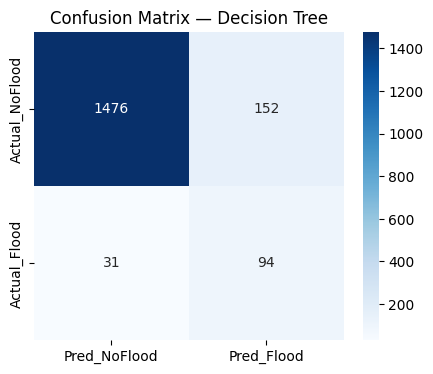


🧾 Classification Report (Decision Tree):
              precision    recall  f1-score   support

    No Flood       0.98      0.91      0.94      1628
       Flood       0.38      0.75      0.51       125

    accuracy                           0.90      1753
   macro avg       0.68      0.83      0.72      1753
weighted avg       0.94      0.90      0.91      1753


📊 PERFORMANCE EVALUATION: RANDOM FOREST
Accuracy:  0.9504
Precision: 0.6727
Recall:    0.5920
F1-Score:  0.6298


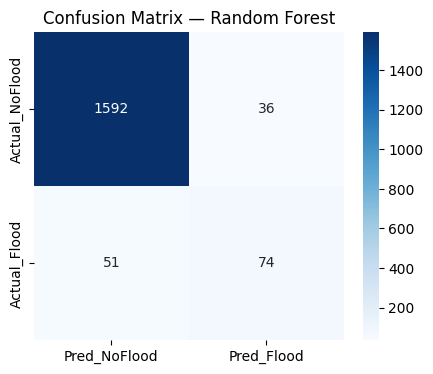


🧾 Classification Report (Random Forest):
              precision    recall  f1-score   support

    No Flood       0.97      0.98      0.97      1628
       Flood       0.67      0.59      0.63       125

    accuracy                           0.95      1753
   macro avg       0.82      0.78      0.80      1753
weighted avg       0.95      0.95      0.95      1753



In [8]:
# ============================================================
# 🔵 CELL 1: DECISION TREE & RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Reshape 3D sequences to 2D for scikit-learn models
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

print(f"Reshaped X_train for ML: {X_train_2d.shape}")

# 2️⃣ Initialize Models
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 3️⃣ Train Models
print("\n🌲 Training Decision Tree...")
dt_model.fit(X_train_2d, y_train)

print("🌳 Training Random Forest...")
rf_model.fit(X_train_2d, y_train)

# 4️⃣ Evaluate Models & Plot Confusion Matrix
for name, model_ml in [("Decision Tree", dt_model), ("Random Forest", rf_model)]:
    y_pred_ml = model_ml.predict(X_test_2d)

    print(f"\n============================================================")
    print(f"📊 PERFORMANCE EVALUATION: {name.upper()}")
    print(f"============================================================")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred_ml):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_ml):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_ml):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred_ml):.4f}")

    # Confusion Matrix + Classification Report
    cm = confusion_matrix(y_test, y_pred_ml)
    cm_df = pd.DataFrame(cm,
                         index=['Actual_NoFlood', 'Actual_Flood'],
                         columns=['Pred_NoFlood', 'Pred_Flood'])

    plt.figure(figsize=(5,4))
    sns.heatmap(cm_df, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    print(f"\n🧾 Classification Report ({name}):")
    print(classification_report(y_test, y_pred_ml, target_names=["No Flood", "Flood"]))


🏗️ CNN Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 6, 64)          │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 128)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,905 (109.00 KB)

 Trainable params: 27,905 (109.00 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training Standalone CNN...
Epoch 1/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8595 - loss: 0.3389 - val_accuracy: 0.9474 - val_loss: 0.1510
Epoch 2/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8962 - loss: 0.2588 - val_accuracy: 0.8820 - val_loss: 0.2569
Epoch 3/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8988 - loss: 0.2457 - val_accuracy: 0.9456 - val_loss: 0.1524
Epoch 4/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9075 - loss: 0.2250 - val_accuracy: 0.9395 - val_loss: 0.1464
Epoch 5/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9099 - loss: 0.2194 - val_accuracy: 0.9413 - val_loss: 0.1430
Epoch 6/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9110 - loss: 0.2173 - val_accuracy: 0.9395 - val_loss: 0.1503
Epoch 7/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9187 - loss: 0.1992 - val_accuracy: 0.9511 - val_loss: 0.1338
Epoch 8/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9211 - l

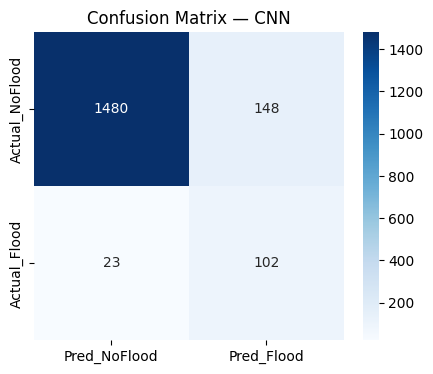


🧾 Classification Report (CNN):
              precision    recall  f1-score   support

    No Flood       0.98      0.91      0.95      1628
       Flood       0.41      0.82      0.54       125

    accuracy                           0.90      1753
   macro avg       0.70      0.86      0.74      1753
weighted avg       0.94      0.90      0.92      1753



In [9]:
# ============================================================
# 🔵 CELL 2: STANDALONE CNN MODEL
# ============================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1️⃣ Define Model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=1),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\n🏗️ CNN Model Architecture:")
cnn_model.summary()

# 2️⃣ Train Model
print("\n🚀 Training Standalone CNN...")
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

# 3️⃣ Evaluate Model
y_pred_prob_cnn = cnn_model.predict(X_test)
y_pred_cnn = (y_pred_prob_cnn > 0.4).astype(int)

print(f"\n============================================================")
print(f"📊 PERFORMANCE EVALUATION: STANDALONE CNN")
print(f"============================================================")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_cnn):.4f}")

# 4️⃣ Confusion Matrix + Classification Report
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
cm_df_cnn = pd.DataFrame(cm_cnn,
                         index=['Actual_NoFlood', 'Actual_Flood'],
                         columns=['Pred_NoFlood', 'Pred_Flood'])

plt.figure(figsize=(5,4))
sns.heatmap(cm_df_cnn, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix — CNN")
plt.show()

print("\n🧾 Classification Report (CNN):")
print(classification_report(y_test, y_pred_cnn, target_names=["No Flood", "Flood"]))


🏗️ LSTM Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 7, 64)          │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,289 (141.75 KB)

 Trainable params: 36,289 (141.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training Standalone LSTM...
Epoch 1/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8459 - loss: 0.3390 - val_accuracy: 0.9462 - val_loss: 0.1373
Epoch 2/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9031 - loss: 0.2389 - val_accuracy: 0.9535 - val_loss: 0.1236
Epoch 3/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9098 - loss: 0.2251 - val_accuracy: 0.9303 - val_loss: 0.1611
Epoch 4/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9083 - loss: 0.2175 - val_accuracy: 0.9419 - val_loss: 0.1412
Epoch 5/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9138 - loss: 0.2079 - val_accuracy: 0.9456 - val_loss: 0.1333
Epoch 6/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9139 - loss: 0.2048 - val_accuracy: 0.9407 - val_loss: 0.1439
Epoch 7/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9162 - loss: 0.1997 - val_accuracy: 0.9468 - val_loss: 0.1272
Epoch 8/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.91

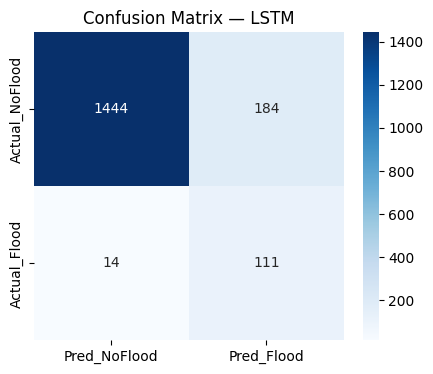


🧾 Classification Report (LSTM):
              precision    recall  f1-score   support

    No Flood       0.99      0.89      0.94      1628
       Flood       0.38      0.89      0.53       125

    accuracy                           0.89      1753
   macro avg       0.68      0.89      0.73      1753
weighted avg       0.95      0.89      0.91      1753



In [10]:
# ============================================================
# 🔵 CELL 3: STANDALONE LSTM MODEL
# ============================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1️⃣ Define Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\n🏗️ LSTM Model Architecture:")
lstm_model.summary()

# 2️⃣ Train Model
print("\n🚀 Training Standalone LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

# 3️⃣ Evaluate Model
y_pred_prob_lstm = lstm_model.predict(X_test)
y_pred_lstm = (y_pred_prob_lstm > 0.4).astype(int)

print(f"\n============================================================")
print(f"📊 PERFORMANCE EVALUATION: STANDALONE LSTM")
print(f"============================================================")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lstm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lstm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lstm):.4f}")

# 4️⃣ Confusion Matrix + Classification Report
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_df_lstm = pd.DataFrame(cm_lstm,
                          index=['Actual_NoFlood', 'Actual_Flood'],
                          columns=['Pred_NoFlood', 'Pred_Flood'])

plt.figure(figsize=(5,4))
sns.heatmap(cm_df_lstm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix — LSTM")
plt.show()

print("\n🧾 Classification Report (LSTM):")
print(classification_report(y_test, y_pred_lstm, target_names=["No Flood", "Flood"]))

#Hyperparameter Tuning - CNN-LSTM

Trial 10 Complete [00h 00m 43s]
val_loss: 0.11764711886644363

Best val_loss So Far: 0.10188033431768417
Total elapsed time: 00h 07m 14s

🏆 Best Hyperparameters Found:
- CNN Filters: 32
- Kernel Size: 2
- LSTM Units: 128
- Dense Units: 64
- Dropout 1: 0.40
- Dropout 2: 0.20
- Learning Rate: 0.001

🚀 Training Final Model with Best Hyperparameters...
Epoch 1/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8462 - loss: 0.3599 - val_accuracy: 0.9303 - val_loss: 0.1771
Epoch 2/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8786 - loss: 0.2905 - val_accuracy: 0.9432 - val_loss: 0.1574
Epoch 3/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8792 - loss: 0.2688 - val_accuracy: 0.9511 - val_loss: 0.1511
Epoch 4/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8865 - loss: 0.2596 - val_accuracy: 0.9432 - val_loss: 0.1404
Epoch 5/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8907 - loss: 0.2551 - val_accuracy: 0.9450 - val_loss: 0.1441
Epoch 6

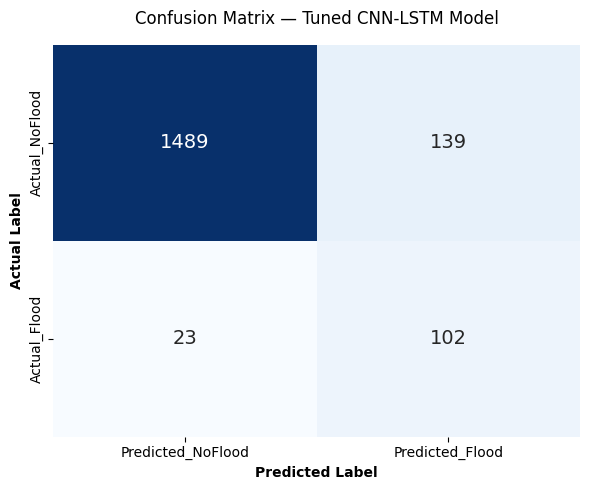


🧾 Confusion Matrix (Table Format):
                Predicted_NoFlood  Predicted_Flood
Actual_NoFlood               1489              139
Actual_Flood                   23              102

Detailed Classification Report:

              precision    recall  f1-score   support

    No Flood       0.98      0.91      0.95      1628
       Flood       0.42      0.82      0.56       125

    accuracy                           0.91      1753
   macro avg       0.70      0.87      0.75      1753
weighted avg       0.94      0.91      0.92      1753



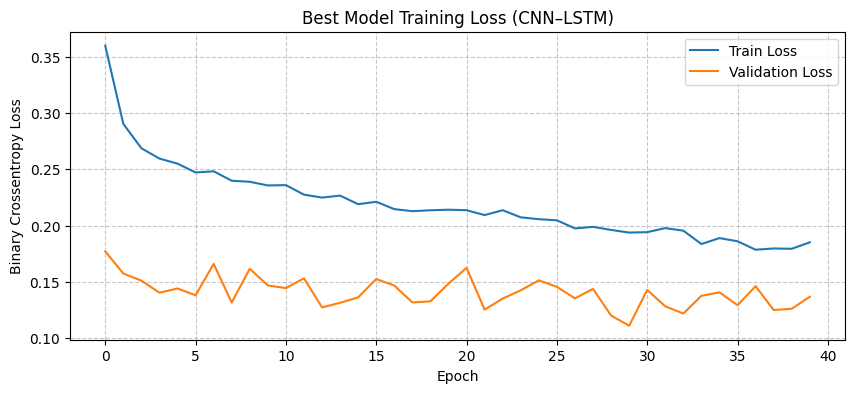

In [11]:
# ============================================================
# 5️⃣ HYPERPARAMETER TUNING — CNN–LSTM Setup
# ============================================================
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

def build_model(hp):
    model = Sequential()

    # Tune CNN Filters & Kernel Size
    hp_filters = hp.Int('filters', min_value=32, max_value=128, step=32)
    hp_kernel = hp.Choice('kernel_size', values=[2, 3])

    model.add(Conv1D(
        filters=hp_filters,
        kernel_size=hp_kernel,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(MaxPooling1D(pool_size=2))

    # Tune First Dropout Rate
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_1))

    # Tune LSTM Units
    hp_lstm_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    model.add(LSTM(hp_lstm_units, return_sequences=False))

    # Tune Dense Layer Units
    hp_dense_units = hp.Int('dense_units', min_value=16, max_value=64, step=16)
    model.add(Dense(hp_dense_units, activation='relu'))

    # Tune Second Dropout Rate
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_2))

    model.add(Dense(1, activation='sigmoid'))

    # Tune Learning Rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Initialize the Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss', # Optimizing for val_loss is usually best for imbalanced data
    max_trials=10,        # Number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='flood_model_tuning',
    project_name='cnn_lstm_optimization'
)

tuner.search_space_summary()

# ============================================================
# 6️⃣ EXECUTING THE SEARCH & TRAINING THE BEST MODEL
# ============================================================

# Handle class imbalance (same as before)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}
print("\n⚖️ Class Weights:", class_weights)

# Early stopping specifically for the tuning phase
tune_es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n🔍 Starting Hyperparameter Search...")
tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=30, # Keep epochs slightly lower for the search phase
    batch_size=16,
    class_weight=class_weights,
    callbacks=[tune_es],
    verbose=1
)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n🏆 Best Hyperparameters Found:")
print(f"- CNN Filters: {best_hps.get('filters')}")
print(f"- Kernel Size: {best_hps.get('kernel_size')}")
print(f"- LSTM Units: {best_hps.get('lstm_units')}")
print(f"- Dense Units: {best_hps.get('dense_units')}")
print(f"- Dropout 1: {best_hps.get('dropout_1'):.2f}")
print(f"- Dropout 2: {best_hps.get('dropout_2'):.2f}")
print(f"- Learning Rate: {best_hps.get('learning_rate')}")

# Build the model with the best hyperparams and train it fully
print("\n🚀 Training Final Model with Best Hyperparameters...")
best_model = tuner.hypermodel.build(best_hps)

# Stricter early stopping for the final training run
final_es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[final_es],
    verbose=1
)

# ============================================================
# 7️⃣ PERFORMANCE EVALUATION (Using Best Model)
# ============================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

y_pred_prob = best_model.predict(X_test)
# Slightly lower threshold to favor flood recall
y_pred = (y_pred_prob > 0.4).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n📊 Best Model Performance Metrics (threshold=0.4):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

# ============================================================
# 8️⃣ CONFUSION MATRIX & REPORT
# ============================================================

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                    index=['Actual_NoFlood', 'Actual_Flood'],
                    columns=['Predicted_NoFlood', 'Predicted_Flood'])

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 14}) # Increased font size for readability
plt.title("Confusion Matrix — Tuned CNN-LSTM Model", pad=15)
plt.ylabel("Actual Label", weight='bold')
plt.xlabel("Predicted Label", weight='bold')
plt.tight_layout()
plt.show()

# Print Table Format (Fallback for non-Jupyter environments)
print("\n🧾 Confusion Matrix (Table Format):")
print(cm_df)

# Print Detailed Classification Report
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Flood', 'Flood']))

# ============================================================
# 9️⃣ TRAINING VISUALIZATION (Optional/Re-added)
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Best Model Training Loss (CNN–LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##Hyper Parameter ChatGPT

In [ ]:
```python
# ============================================================
# 🚀 CNN–LSTM Hyperparameter Tuning
# ============================================================

# Install dependency
!pip install -q keras-tuner

# ============================================================
# 📦 Imports
# ============================================================

import numpy as np
import pandas as pd
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 1️⃣ DATA MERGING
# ============================================================

merged = pd.merge(
    daily_df,
    discharge_df,
    on=["date", "location"],
    suffixes=("_weather", "_flood")
).dropna(subset=["river_discharge_m3s"])

print(f"\n✅ Merged dataset: {len(merged)} rows")

# ============================================================
# 2️⃣ FEATURE SELECTION
# ============================================================

feature_cols = [
    "rain_sum_mm", "precipitation_sum_mm", "temperature_mean_°C",
    "wind_speed_max_mps", "wind_gust_max_mps", "atmo_index",
    "temp_wind_interaction", "rain_lag_1d", "rain_lag_3d",
    "rain_rolling_3d", "rain_cum_7d",
    "rain_sum_zscore", "temperature_mean_zscore", "wind_speed_zscore",
    "is_extreme_weather",
    "discharge_lag_1d", "discharge_lag_3d", "discharge_rolling_3d",
    "discharge_cum_7d", "discharge_delta_1d", "discharge_anomaly",
    "discharge_zscore",
    "dayofyear_flood", "month_flood", "weekday_flood"
]

feature_cols = [c for c in feature_cols if c in merged.columns]

# ============================================================
# 3️⃣ TARGET VARIABLE
# ============================================================

if "is_extreme_flood" in merged.columns:
    merged["flood_label"] = merged["is_extreme_flood"]
else:
    threshold = merged["river_discharge_m3s"].quantile(0.8)
    merged["flood_label"] = (merged["river_discharge_m3s"] >= threshold).astype(int)

print(f"Flood ratio: {merged['flood_label'].mean():.3f}")

# ============================================================
# 4️⃣ SCALING & SEQUENCES
# ============================================================

scaler = StandardScaler()
scaled_features = scaler.fit_transform(merged[feature_cols])

scaled_df = pd.DataFrame(scaled_features, columns=feature_cols)
scaled_df["flood_label"] = merged["flood_label"].values

def create_sequences(data, labels, lookback=7):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(labels[i])
    return np.array(X), np.array(y)

X, y = create_sequences(
    scaled_df[feature_cols].values,
    scaled_df["flood_label"].values,
    lookback=7
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ============================================================
# 5️⃣ CLASS WEIGHTS
# ============================================================

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}

print("Class weights:", class_weights)

# ============================================================
# 6️⃣ MODEL BUILDER (TUNING SPACE)
# ============================================================

def build_model(hp):
    model = Sequential()

    model.add(Conv1D(
        filters=hp.Int('filters', 32, 128, step=32),
        kernel_size=hp.Choice('kernel_size', [2, 3]),
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))

    model.add(MaxPooling1D(2))

    model.add(Dropout(hp.Float('dropout_cnn', 0.2, 0.5, step=0.1)))

    model.add(LSTM(
        units=hp.Int('lstm_units', 32, 128, step=32),
        return_sequences=False
    ))

    model.add(Dense(
        units=hp.Int('dense_units', 16, 64, step=16),
        activation='relu'
    ))

    model.add(Dropout(hp.Float('dropout_dense', 0.2, 0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'rmsprop']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ============================================================
# 7️⃣ TUNER SETUP
# ============================================================

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='cnn_lstm_tuning',
    project_name='flood_prediction'
)

# ============================================================
# 8️⃣ HYPERPARAMETER SEARCH
# ============================================================

tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)],
    verbose=1
)

# ============================================================
# 9️⃣ BEST MODEL
# ============================================================

best_hps = tuner.get_best_hyperparameters(1)[0]

print("\nBest Hyperparameters:")
for param in ['filters', 'kernel_size', 'lstm_units', 'dense_units', 'optimizer']:
    print(f"{param}: {best_hps.get(param)}")

best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10)],
    verbose=1
)

# ============================================================
# 🔟 EVALUATION
# ============================================================

y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.4).astype(int)

print("\n📊 Final Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# 📊 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Tuned CNN-LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 📉 TRAINING CURVES
# ============================================================

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()


##Hyper Parameter Gemini


In [ ]:
# ============================================================
# 5️⃣ HYPERPARAMETER TUNING — CNN–LSTM (using KerasTuner)
# ============================================================

import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

# Define a model-building function for KerasTuner
def build_model(hp):
    model = Sequential()

    # Tune the number of filters and kernel size for Conv1D
    hp_filters = hp.Int('conv_filters', min_value=32, max_value=128, step=32)
    hp_kernel = hp.Choice('conv_kernel', values=[2, 3])

    model.add(Conv1D(
        filters=hp_filters,
        kernel_size=hp_kernel,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(MaxPooling1D(pool_size=2))

    # Tune dropout rate
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_1))

    # Tune the number of LSTM units
    hp_lstm_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    model.add(LSTM(hp_lstm_units, return_sequences=False))

    # Tune Dense layer units
    hp_dense_units = hp.Int('dense_units', min_value=16, max_value=64, step=16)
    model.add(Dense(hp_dense_units, activation='relu'))

    # Tune second dropout rate
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_2))

    model.add(Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

print("\n🔍 Initializing KerasTuner (Hyperband)...")

# Initialize the Hyperband tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_loss', # Optimize for validation loss
    max_epochs=60,        # Max epochs per trial (matches your original setup)
    factor=3,             # Reduction factor for Hyperband
    directory='tuning_dir',
    project_name='flood_cnn_lstm_tuning'
)

# Handle class imbalance (From your Step 6)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}
print("\n⚖️ Class Weights:", class_weights)

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ============================================================
# 6️⃣ RUN TUNING SEARCH
# ============================================================

print("\n🚀 Starting hyperparameter search...")

tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n🏆 Optimal Hyperparameters Found:")
print(f"- Conv1D Filters: {best_hps.get('conv_filters')}")
print(f"- Conv1D Kernel Size: {best_hps.get('conv_kernel')}")
print(f"- Conv1D Dropout: {best_hps.get('dropout_1'):.2f}")
print(f"- LSTM Units: {best_hps.get('lstm_units')}")
print(f"- Dense Units: {best_hps.get('dense_units')}")
print(f"- Dense Dropout: {best_hps.get('dropout_2'):.2f}")
print(f"- Learning Rate: {best_hps.get('learning_rate')}")

# ============================================================
# 6B️⃣ TRAIN THE BEST MODEL
# ============================================================

print("\n🏋️ Training the final model with the best hyperparameters...")

# Build the model with the optimal hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Train the optimal model (you can optionally increase epochs here since ES will stop it anyway)
history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

# Replace 'model' with 'best_model' for your subsequent Evaluation (Step 7)
model = best_model

Trial 90 Complete [00h 01m 03s]
val_loss: 0.12231422960758209

Best val_loss So Far: 0.10470247268676758
Total elapsed time: 00h 45m 22s

🏆 Optimal Hyperparameters Found:
- Conv1D Filters: 64
- Conv1D Kernel Size: 2
- Conv1D Dropout: 0.30
- LSTM Units: 32
- Dense Units: 16
- Dense Dropout: 0.20
- Learning Rate: 0.001

🏋️ Training the final model with the best hyperparameters...
Epoch 1/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8240 - loss: 0.3642 - val_accuracy: 0.9193 - val_loss: 0.1901
Epoch 2/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8901 - loss: 0.2764 - val_accuracy: 0.9529 - val_loss: 0.1513
Epoch 3/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8945 - loss: 0.2549 - val_accuracy: 0.9267 - val_loss: 0.1763
Epoch 4/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9024 - loss: 0.2389 - val_accuracy: 0.9120 - val_loss: 0.1991
Epoch 5/60
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8997 - loss: 0.2412 - val_accuracy: 0.937